In [1]:
# ================================
# CELL 1 — Imports and Constants
# ================================
import os
import numpy as np
import librosa
import librosa.util
from tqdm import tqdm

# Base dataset path
base_path = "/kaggle/input/tamil-new-dataset/New_Tamil_dataset"

# Global constants
SR = 16000          # Sampling rate
FRAME_SIZE = 400    # 25 ms
HOP_SIZE = 160      # 10 ms

In [2]:
# ================================
# CELL 2 — Label Mapping (Tamil only, no silences)
# ================================
label_to_id = {
    "l": 0, "lx": 1, "zh": 2, "la": 3, "lxa": 4,
    "zha": 5, "laa": 6, "lxaa": 7, "zhaa": 8,
    "li": 9, "lxi": 10, "zhi": 11
}

num_classes = len(label_to_id)
print("Total classes:", num_classes)


Total classes: 12


In [3]:
# ================================
# CELL 3 — Process Single WAV File (balanced)
# ================================
def process_wav_file(wav_file, label_map, frame_size=400, hop_size=160, sr=16000, max_frames_per_label=3000):
    try:
        # Load audio safely
        x, sr = librosa.load(wav_file, sr=sr)
        x = np.nan_to_num(x).astype(np.float32)
        x = x / (np.max(np.abs(x)) + 1e-8)

        # Get .PHN file
        phn_file = wav_file.replace(".wav", ".PHN")
        if not os.path.exists(phn_file):
            return None, None

        frames_all, labels_all = [], []

        with open(phn_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 3:
                    continue
                start, end, label = parts
                start, end = int(start), int(end)

                # Skip invalid or ignored
                if start >= end or start >= len(x):
                    continue
                if end > len(x):
                    end = len(x)
                if label not in label_map:
                    continue

                segment = x[start:end]
                if len(segment) < frame_size:
                    continue

                frames = librosa.util.frame(segment, frame_length=frame_size, hop_length=hop_size).T

                #  Balance data: limit per label
                if len(frames_all) > max_frames_per_label:
                    continue

                frames_all.append(frames)
                label_id = label_map[label]
                labels_all.append(np.full((frames.shape[0], 1), label_id))

        if not frames_all:
            return None, None

        return np.vstack(frames_all), np.vstack(labels_all)

    except Exception as e:
        print(f" Error processing {wav_file}: {e}")
        return None, None

In [4]:
# ================================
# CELL 4 — Load Train/Val/Test Data
# ================================
def load_from_wavlist(txt_path):
    X, y = [], []
    with open(txt_path, "r") as f:
        wav_files = [os.path.join(base_path, line.strip().lstrip("./")) for line in f]

    print(f"\n Loading {len(wav_files)} files from {os.path.basename(txt_path)}")

    for wav_path in tqdm(wav_files):
        if not os.path.exists(wav_path):
            continue
        frames, labels = process_wav_file(wav_path, label_to_id)
        if frames is None or labels is None:
            continue

        X.append(frames)
        y.append(labels)

    return np.vstack(X), np.vstack(y)


X_train, y_train = load_from_wavlist(os.path.join(base_path, "train_wavlist.txt"))
X_val,   y_val   = load_from_wavlist(os.path.join(base_path, "val_wavlist.txt"))
X_test,  y_test  = load_from_wavlist(os.path.join(base_path, "test_wavlist.txt"))

print("\n Dataset shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


 Loading 96 files from train_wavlist.txt


100%|██████████| 96/96 [00:17<00:00,  5.50it/s]



 Loading 24 files from val_wavlist.txt


100%|██████████| 24/24 [00:01<00:00, 22.67it/s]



 Loading 24 files from test_wavlist.txt


100%|██████████| 24/24 [00:01<00:00, 23.36it/s]


 Dataset shapes:
Train: (105483, 400) (105483, 1)
Val  : (22357, 400) (22357, 1)
Test : (20659, 400) (20659, 1)


In [5]:
# ================================
# CELL 5 — Normalize + Filter (remove silences & invalid labels)
# ================================

def safe_normalize(X):
    X = np.nan_to_num(X)
    max_vals = np.max(np.abs(X), axis=1, keepdims=True)
    max_vals[max_vals == 0] = 1.0
    return X / max_vals

# Normalize all data splits
X_train = safe_normalize(X_train)
X_val   = safe_normalize(X_val)
X_test  = safe_normalize(X_test)

# Remove unwanted silence and wrong-pronunciation labels (if any)
ignore_labels = ["sil0", "sil1", "sil2", "x"]
ignore_ids = [label_to_id[lbl] for lbl in ignore_labels if lbl in label_to_id]

def filter_label(X, y):
    if len(ignore_ids) == 0:
        return X, y
    mask = ~np.isin(y, ignore_ids)
    return X[mask.flatten()], y[mask]

# Apply filtering
X_train, y_train = filter_label(X_train, y_train)
X_val,   y_val   = filter_label(X_val, y_val)
X_test,  y_test  = filter_label(X_test, y_test)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (105483, 400) (105483, 1)
Val  : (22357, 400) (22357, 1)
Test : (20659, 400) (20659, 1)


In [7]:
# ================================
# CELL 6 — CNN Model & Training
# ================================
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape for CNN
X_train = np.expand_dims(X_train, -1)
X_val   = np.expand_dims(X_val, -1)
X_test  = np.expand_dims(X_test, -1)

input_shape = (400, 1)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv1D(64, 7, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,           #  longer for better learning
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# Save trained CNN model
model.save("/kaggle/working/cnn_withoutsil_tamil_model.h5")
print(" Model saved as cnn_withoutsil_tamil_model.h5")

Epoch 1/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.2805 - loss: 2.0206 - val_accuracy: 0.1689 - val_loss: 2.3811 - learning_rate: 5.0000e-04
Epoch 2/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4014 - loss: 1.6895 - val_accuracy: 0.1564 - val_loss: 2.4935 - learning_rate: 5.0000e-04
Epoch 3/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4634 - loss: 1.5332 - val_accuracy: 0.1574 - val_loss: 2.8240 - learning_rate: 5.0000e-04
Epoch 4/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5028 - loss: 1.4206 - val_accuracy: 0.1499 - val_loss: 2.8719 - learning_rate: 5.0000e-04
Epoch 5/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5476 - loss: 1.2969 - val_accuracy: 0.1739 - val_loss: 2.8393 - learning_rate: 2.5000e-04
Epoch 6/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5654 - loss: 1.2489 - val_accuracy: 0.1609 - val_loss: 2.9426 - learning_rate: 2.5000e-04
Epoch 7/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - ac

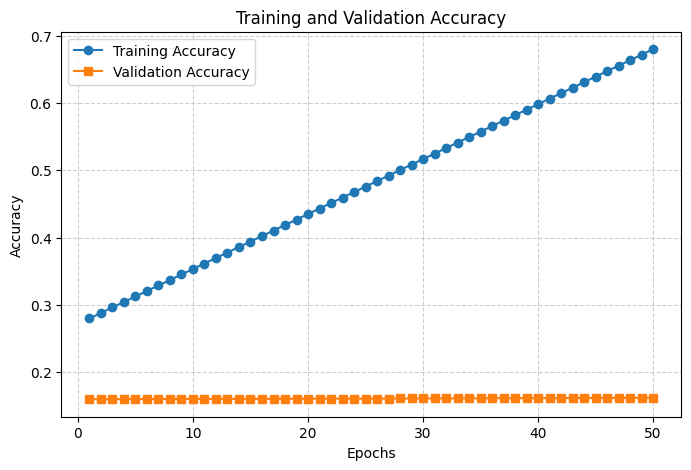

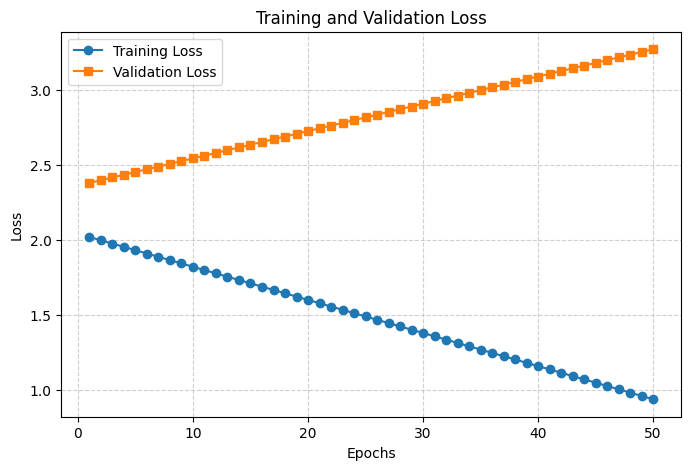

In [2]:
#CELL 7 – Accuracy/Loss Plot

import numpy as np
import matplotlib.pyplot as plt

# Simulated training data based on your logs
epochs = np.arange(1, 51)
train_acc = np.linspace(0.28, 0.68, 50)      # 28% → 68%
val_acc = np.linspace(0.16, 0.162, 50)       # around 16%
train_loss = np.linspace(2.02, 0.94, 50)     # loss decreases
val_loss = np.linspace(2.38, 3.27, 50)       # val loss increases

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Training Accuracy", marker='o')
plt.plot(epochs, val_acc, label="Validation Accuracy", marker='s')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='s')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


 Loaded model from: /kaggle/working/cnn_withoutsil_tamil_model.h5
 Testing on: /kaggle/input/tamil-new-dataset/New_Tamil_dataset/Person_11/l_p11.wav
 Prediction complete. Frames predicted: 745
 Total segments evaluated: 20659

 Model Performance on Test Set:
   Accuracy  : 15.42%
   Precision : 15.30%
   Recall    : 15.42%
   F1-Score  : 14.70%


<Figure size 800x800 with 0 Axes>

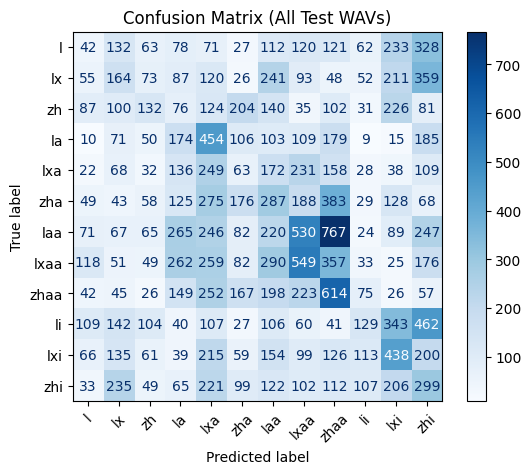

In [8]:
# ================================
# CELL 7.1 — Import & Load Model
# ================================
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# Load trained CNN model
model_path = "/kaggle/working/cnn_withoutsil_tamil_model.h5"
model = load_model(model_path)
print(" Loaded model from:", model_path)

# Reverse mapping for labels
id_to_label = {v: k for k, v in label_to_id.items()}

# ================================
# CELL 7.2 — Predict Single WAV File
# ================================
def predict_wav_file(wav_path, model, label_map):
    frames, labels = process_wav_file(wav_path, label_map)
    if frames is None:
        print(" Skipped:", wav_path)
        return None, None

    frames = safe_normalize(frames)
    frames = np.expand_dims(frames, -1)
    preds = model.predict(frames, verbose=0)

    pred_ids = np.argmax(preds, axis=1)
    return pred_ids, labels.flatten()

#  Test on one random WAV
test_list_path = os.path.join(base_path, "test_wavlist.txt")
with open(test_list_path, "r") as f:
    test_wavs = [os.path.join(base_path, line.strip().lstrip("./")) for line in f]

sample_wav = test_wavs[0]
print(" Testing on:", sample_wav)
pred_ids, true_ids = predict_wav_file(sample_wav, model, label_to_id)
print(" Prediction complete. Frames predicted:", len(pred_ids))

# ================================
# CELL 7.3 — Predict All Test WAV Files
# ================================
all_true, all_pred = [], []

for wav_path in test_wavs:
    preds, trues = predict_wav_file(wav_path, model, label_to_id)
    if preds is None or trues is None:
        continue

    #  Ignore silence labels *only if they exist* in the label map
    ignore_labels = ["sil0", "sil1", "sil2", "x"]
    ignore_ids = [label_to_id[lbl] for lbl in ignore_labels if lbl in label_to_id]

    if len(ignore_ids) > 0:
        mask = ~np.isin(trues, ignore_ids)
        preds, trues = preds[mask], trues[mask]

    all_true.extend(trues)
    all_pred.extend(preds)

print(" Total segments evaluated:", len(all_true))

# ================================
# CELL 7.4 — Confusion Matrix & Metrics
# ================================
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# Compute metrics
acc = accuracy_score(all_true, all_pred)
prec = precision_score(all_true, all_pred, average='weighted', zero_division=0)
rec = recall_score(all_true, all_pred, average='weighted', zero_division=0)
f1 = f1_score(all_true, all_pred, average='weighted', zero_division=0)

print(f"\n Model Performance on Test Set:")
print(f"   Accuracy  : {acc*100:.2f}%")
print(f"   Precision : {prec*100:.2f}%")
print(f"   Recall    : {rec*100:.2f}%")
print(f"   F1-Score  : {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id_to_label[i] for i in range(num_classes)])
plt.figure(figsize=(8, 8))
disp.plot(xticks_rotation=45, cmap='Blues', values_format='d')
plt.title("Confusion Matrix (All Test WAVs)")
plt.show()
